У цьому ДЗ ми попрактикуємось моделювати часові ряди на даних з [Store Item Demand Forecasting Challenge](https://www.kaggle.com/competitions/demand-forecasting-kernels-only/overview). Ми будемо працювати лише з тренувальними даними цього змагання і задача у нас буде дещо змінена. Фокус буде на пошуці найкращої моделі, експериментах і використанні функціоналу `darts`.

Якщо якісно попрацювати в цьому завданні - це буде чудовий приклад проєкту для вашого портфоліо: "спрогнозував(-ла) поденні продажі на 1 міс для 50 товарів в 10 магазинах" звучить вражаюче! Але ми в рамках ДЗ для оптимізації часу сконцентруємось на моделюванні продажів одного товару в одному магазині.

**Задача**

Вам надано дані про продажі товарів у магазинах за 5 років. Хочемо навчитись передачати продажі в наступному місяці поденно кожного з 50 товарів у кожному з 10 магазинів. Відповідно будемо проводити експерименти, аби знайти найкращу модель для цього.

На відміну від змагання, ми будемо використовувати метрику МАРЕ (Mean Absolute Percentage Error) замість SMAPE (Symmetric Mean Absolute Percentage Error). Проте, ви також можете розрахувати SMAPE і подати свої результати через late submission на Kaggle.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
import json, os, re

src = '/content/drive/MyDrive/ML/HW ML/Копия блокнота "HW 2.5 Time Series Analysis.ipynb"'
dst = re.sub(r"\.ipynb$", "_clean.ipynb", src)

with open(src, "r", encoding="utf-8") as f:
    nb = json.load(f)

# 1) приберемо глобальні віджети
nb.setdefault("metadata", {}).pop("widgets", None)

# 2) приберемо віджет-метадані з клітинок (на всяк випадок)
for c in nb.get("cells", []):
    md = c.setdefault("metadata", {})
    md.pop("widgets", None)

with open(dst, "w", encoding="utf-8") as f:
    json.dump(nb, f, ensure_ascii=False)

print("Готово! Збережено:", dst)


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/ML/HW ML/Копия блокнота "HW 2.5 Time Series Analysis.ipynb"'

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import plotly.express as px
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_pacf

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("drive/MyDrive/Colab Notebooks/Дані/train.csv.zip")

1. Завантажуємо дані в Pandas.

  1. Завантажте дані з файлу `train.csv.zip` за допомогою бібліотеки Pandas.
  2. Перетворіть колонку `date` на формат `datetime`.
  3. Встановіть колонку `date` як індекс для датафрейму.
  4. Виведіть перші 10 рядків отриманого датафрейму та інформацію про датафрейм.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [ ]:
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

In [ ]:
df

,store,item,sales
date,,,
2013-01-01,1,1,13
2013-01-02,1,1,11
2013-01-03,1,1,14
2013-01-04,1,1,13
2013-01-05,1,1,10
...,...,...,...
2017-12-27,10,50,63
2017-12-28,10,50,59
2017-12-29,10,50,74


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 913000 entries, 2013-01-01 to 2017-12-31
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   store   913000 non-null  int64
 1   item    913000 non-null  int64
 2   sales   913000 non-null  int64
dtypes: int64(3)
memory usage: 27.9 MB


  2. Давайте трошки зрозуміємо дані. У нас 10 магазинів і 50 айтемів в кожному. Хочемо зрозуміти, чи відрізняється динаміка по кожному айтему в магазинах. Як би ви це візуалізували? Побудуйте 3 графіка, які вам допоможуть. Можна використати будь-який інструмент: matplotlib, seaborn, plotly.

  Напишіть висновок з побудованих вами візуалізацій.
  
    **Підказка**: я б спробувала вивести середнє значення і довірчий інтервал (який включає весь діапазон значень з різних магазинів) для динаміки кожного айтема, або принаймні для декількох айтемів, аби зрозуміти тенденцію.



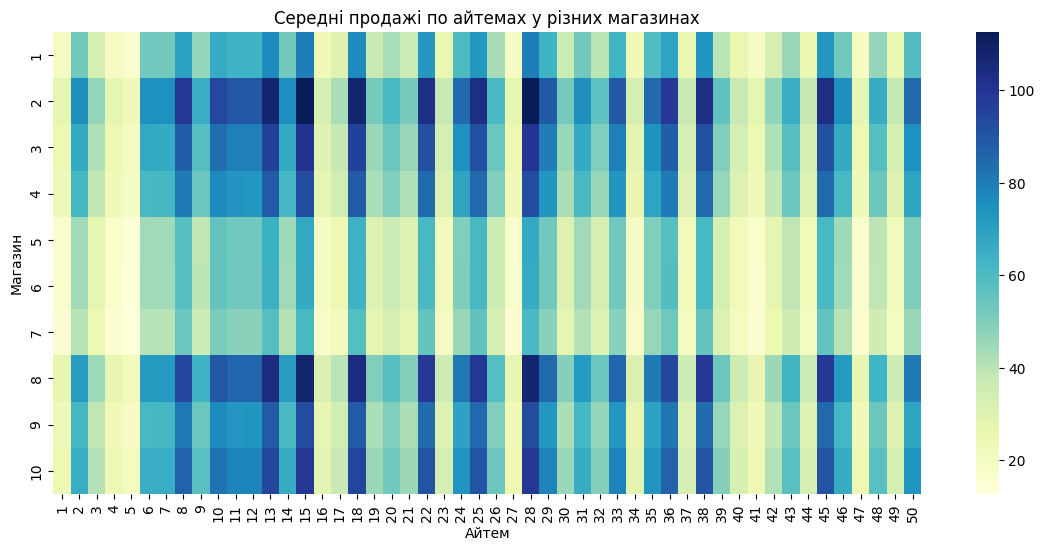

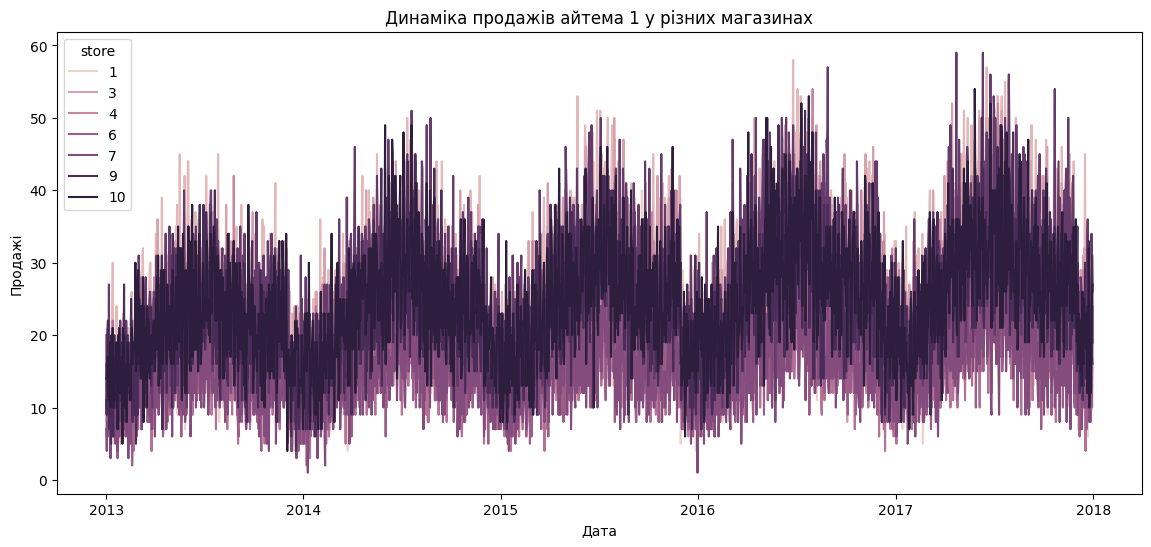

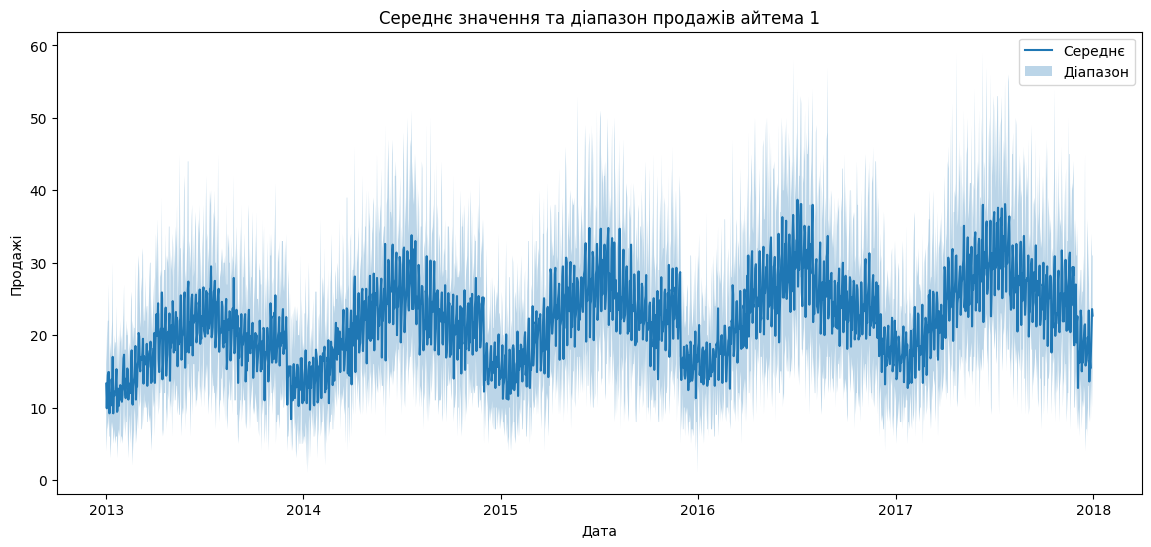

In [ ]:
# 1️⃣ Середні продажі по айтемах і магазинах (теплова карта)
avg_sales = df.groupby(['store', 'item'])['sales'].mean().unstack()
plt.figure(figsize=(14, 6))
sns.heatmap(avg_sales, cmap="YlGnBu")
plt.title("Середні продажі по айтемах у різних магазинах")
plt.xlabel("Айтем")
plt.ylabel("Магазин")
plt.show()

# 2️⃣ Динаміка продажів айтема 1 у всіх магазинах
item_id = 1
df_item1 = df[df['item'] == item_id].groupby(['date', 'store'])['sales'].mean().reset_index()
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_item1, x='date', y='sales', hue='store')
plt.title(f"Динаміка продажів айтема {item_id} у різних магазинах")
plt.xlabel("Дата")
plt.ylabel("Продажі")
plt.show()

# 3️⃣ Середнє та діапазон продажів айтема 1 (усі магазини)
df_item1_mean = df[df['item'] == item_id].groupby('date')['sales'].agg(['mean', 'min', 'max']).reset_index()
plt.figure(figsize=(14, 6))
plt.plot(df_item1_mean['date'], df_item1_mean['mean'], label='Середнє')
plt.fill_between(df_item1_mean['date'], df_item1_mean['min'], df_item1_mean['max'], alpha=0.3, label='Діапазон')
plt.title(f"Середнє значення та діапазон продажів айтема {item_id}")
plt.xlabel("Дата")
plt.ylabel("Продажі")
plt.legend()
plt.show()

Ось що можна сказати з цих трьох графіків:

1. Теплова карта середніх продажів (графік 1)

Видно, що середні продажі відрізняються не лише між товарами, але й між магазинами.

Є товари з високим і стабільним попитом у кількох магазинах (темно-сині стовпці) та товари з низьким попитом (світлі зони).

Деякі магазини мають схожі патерни попиту, інші — значно відрізняються.

2. Динаміка продажів айтема 1 (графік 2)

Усі магазини показують чітку сезонність — піки приблизно раз на рік.

Хоча форма кривої схожа, рівні продажів у різних магазинах трохи відрізняються.

Є періоди падіння, що співпадають у всіх магазинах, що вказує на глобальні фактори (наприклад, свята або сезони).

3. Середнє та діапазон продажів айтема 1 (графік 3)

Середнє значення показує стабільну сезонну структуру з регулярними піками.

Діапазон (min–max) іноді досить широкий — це означає, що у різних магазинах попит на один і той же товар у ті самі дні може сильно різнитися.

Є певна стабільність у формі кривої, тож модель зможе врахувати сезонність.

Висновок:

Продажі залежать і від товару, і від магазину.

Є чітка сезонність, спільна для всіх магазинів, але рівень попиту варіюється.

Для моделювання можна використовувати як глобальні моделі (враховують всі магазини), так і локальні моделі для кожного магазину/товару окремо.

3. **Для початку проаналізуємо лише один ряд, а далі зможемо зациклити тренування моделей.**
  
  Виберіть підмножину даних, що відповідає продажам товару з `item == 1` у магазині з `store == 1`.

  Зробіть декомпозицію цього рядку за адитивною моделлю на тренд, сезонність і залишки з бібліотекою `statsmodels`.

  Зробіть висновки з отриманих візуалізацій. Чи щось би могло вам допомогти ліпше зрозуміти ці візуалізації? (з точки зору обробки даних)

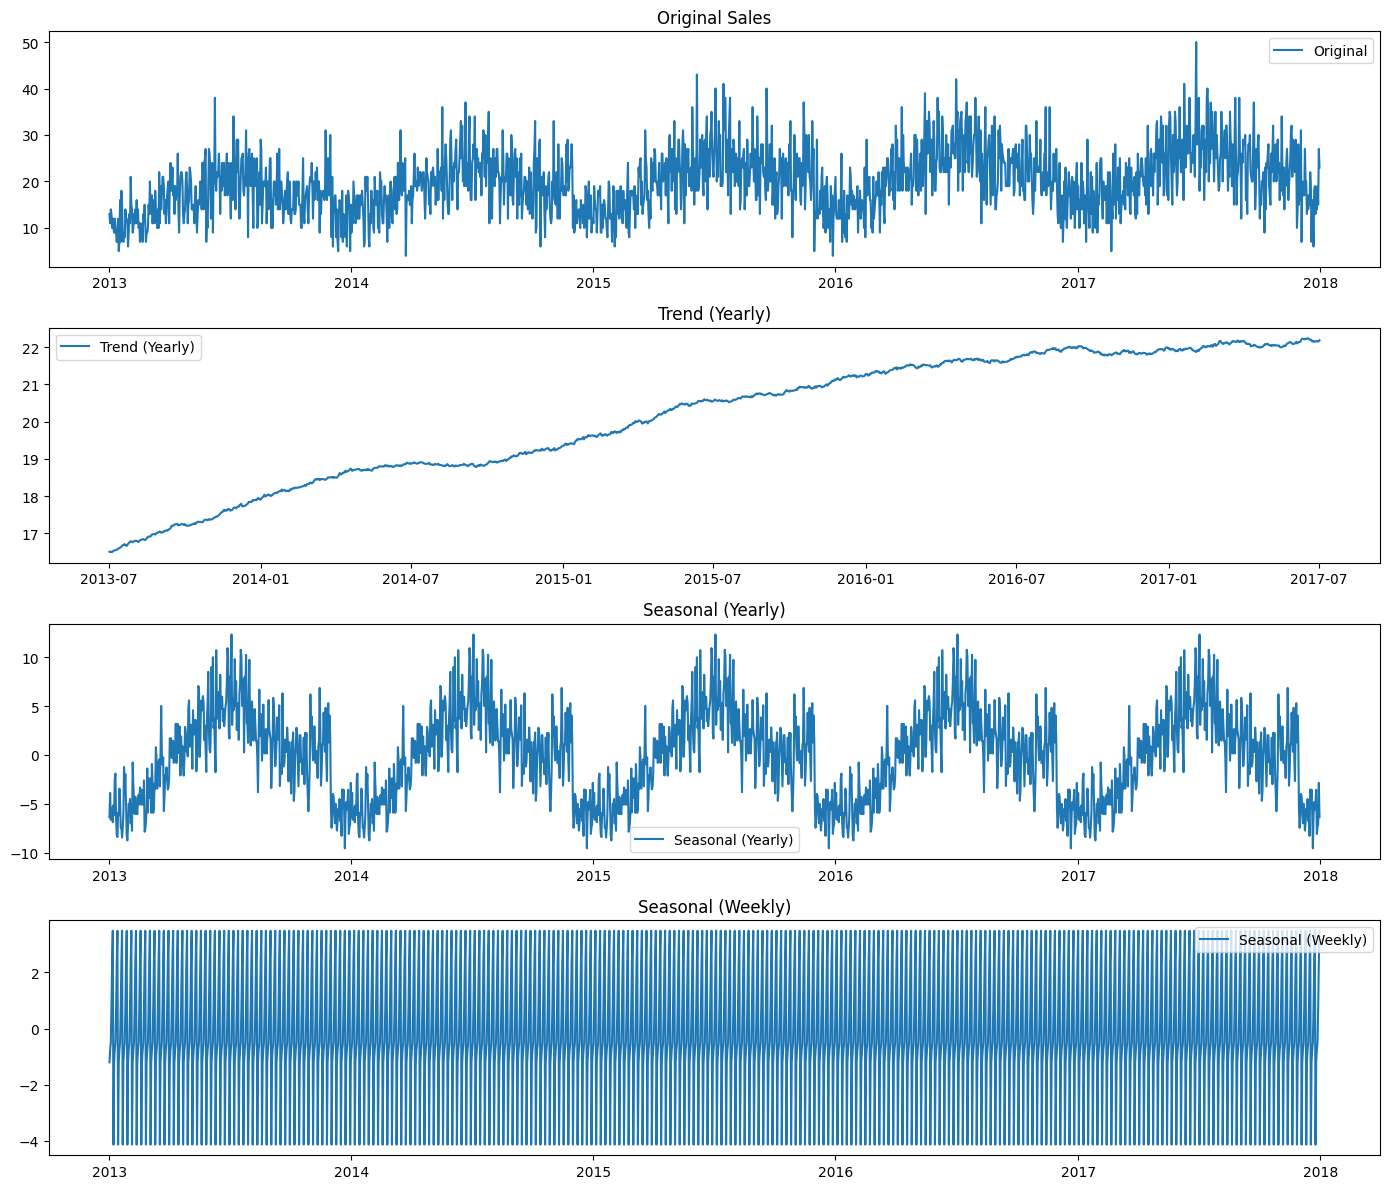

In [ ]:
# Підмножина: товар 1, магазин 1
df_sub = df[(df['item'] == 1) & (df['store'] == 1)].copy()
df_sub = df_sub.sort_index()

# 1️⃣ Перша декомпозиція — річна сезонність
result_year = seasonal_decompose(df_sub['sales'], model='additive', period=365)
residuals_year = df_sub['sales'] - result_year.seasonal  # прибираємо річну сезонність

# 2️⃣ Друга декомпозиція — тижнева сезонність на залишках
result_week = seasonal_decompose(residuals_year, model='additive', period=7)

# Візуалізація
plt.figure(figsize=(14, 12))

plt.subplot(4, 1, 1)
plt.plot(df_sub.index, df_sub['sales'], label='Original')
plt.title("Original Sales")
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(result_year.trend, label='Trend (Yearly)')
plt.title("Trend (Yearly)")
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(result_year.seasonal, label='Seasonal (Yearly)')
plt.title("Seasonal (Yearly)")
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(result_week.seasonal, label='Seasonal (Weekly)')
plt.title("Seasonal (Weekly)")
plt.legend()

plt.tight_layout()
plt.show()

1. Річна сезонність (Seasonal Yearly)

Великі хвилі повторюються приблизно раз на рік.

Піки й спади стабільно збігаються за роками, що свідчить про календарні або погодні фактори (свята, пори року).

2. Тижнева сезонність (Seasonal Weekly)

Виразний 7-денний цикл з повторюваними піками й спадами.

Швидше за все, це різниця між вихідними та робочими днями.

3. Тренд (Trend Yearly)

Повільне зростання з 2013 до приблизно початку 2017 року, далі — стабілізація.

Це може бути насичення ринку або стабілізація попиту на цей товар.

4. Зі створеної підможени даних в попередньому пункті створіть обʼєкт класу `TimeSeries` в `darts` лише для колонки `sales`.

In [ ]:
!pip install darts --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.0/340.0 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 101.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 84.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
from darts import TimeSeries

# Створення TimeSeries лише з колонки 'sales'
series = TimeSeries.from_dataframe(
    df_sub,           # твоя підмножина з item=1, store=1
    value_cols='sales'  # лише колонка sales
)

print(series)

<TimeSeries (DataArray) (date: 1826, component: 1, sample: 1)> Size: 15kB
array([[[13.]],

       [[11.]],

       [[14.]],

       ...,

       [[15.]],

       [[27.]],

       [[23.]]])
Coordinates:
  * date       (date) datetime64[ns] 15kB 2013-01-01 2013-01-02 ... 2017-12-31
  * component  (component) object 8B 'sales'
Dimensions without coordinates: sample
Attributes:
    static_covariates:  None
    hierarchy:          None
    metadata:           None


5. Використовуючи метод `series.split_before` розбийте дані на тренування і валідацію так, аби валідація починалась з `2017-10-01` включно.

  Візуалізуйте на одному графіку тренувальну і валідаційну частину як було показано в лекції.

train: 2013-01-01 00:00:00 → 2017-09-30 00:00:00
val:   2017-10-01 00:00:00 → 2017-12-31 00:00:00


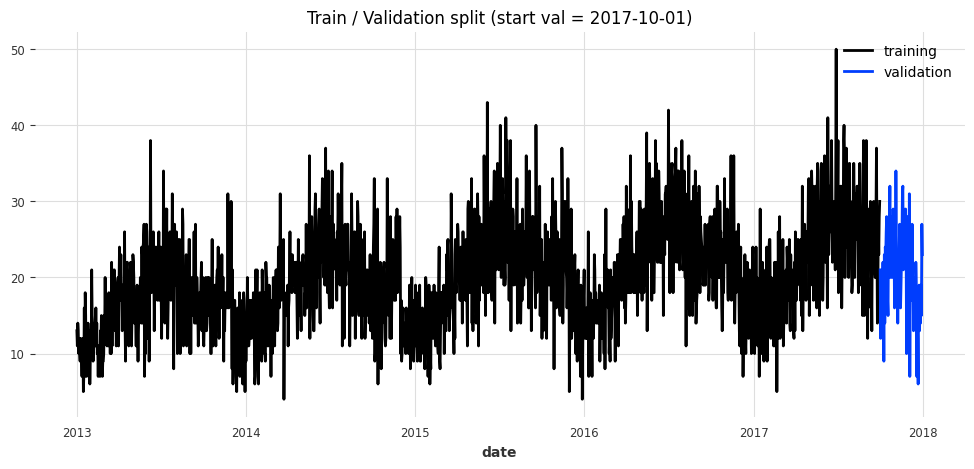

In [ ]:
# ✅ split: train закінчується ДО 2017-10-01, val починається З 2017-10-01
train, val = series.split_before(pd.Timestamp("2017-10-01"))

# перевірка кордонів
print("train:", train.start_time(), "→", train.end_time())
print("val:  ", val.start_time(),   "→", val.end_time())

# візуалізація на одному графіку
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))
train.plot(label="training")
val.plot(label="validation")
plt.title("Train / Validation split (start val = 2017-10-01)")
plt.legend()
plt.show()

6. Побудуйте часткову автокореляційну фукнцію для цього нашого ряду в `series`. Напишіть висновки - які лаги є важливими для прогнозування?

<Figure size 1000x500 with 0 Axes>

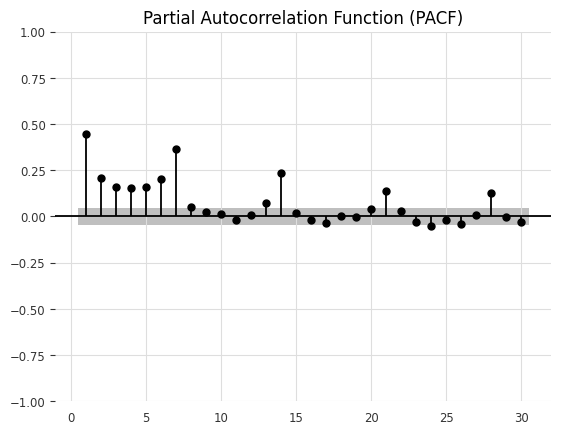

In [ ]:
# Отримуємо значення з TimeSeries у формат numpy
sales_values = series.values().flatten()

# Побудова PACF
plt.figure(figsize=(10, 5))
plot_pacf(sales_values, lags=30, method='ywm', zero=False)
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

7. Виявіть сезональність тренувального ряду використовуючи фукнкцію `check_seasonality` з `darts`.

In [ ]:
from darts.utils.statistics import check_seasonality

def show_seasonality(ts, m, alpha=0.05):
    # важливо: max_lag має бути >= m
    is_seas, used_m = check_seasonality(ts, m=m, alpha=alpha, max_lag=max(m, 400))
    print(f"m={m:>4}: seasonal={is_seas}, used_m={used_m}")

# тренувальна частина
show_seasonality(train, m=7)     # тижнева
show_seasonality(train, m=14)    # 2 тижні (гармоніка)
show_seasonality(train, m=28)    # 4 тижні
show_seasonality(train, m=365)   # річна

m=   7: seasonal=True, used_m=7
m=  14: seasonal=True, used_m=14
m=  28: seasonal=True, used_m=28
m= 365: seasonal=False, used_m=365


8. Побудуйте наївну модель NaiveSeasonal + NaieDrift для прогнозування даних. Кількість кроків для прогнозування визначіть зі свого аналізу в попередніх пунктах. Візуалізайте передбачення проти справжніх даних так, аби було видно якість передбачень. Зробіть висновок про модель. Вона точна?

  Якщо у вас є ідеї, як поліпшити якість передбачення саме наївними моделями - реалізуйте їх в цьому пункті :)

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x786934252c00>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.11/ctypes/__init__.py", line 376, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error


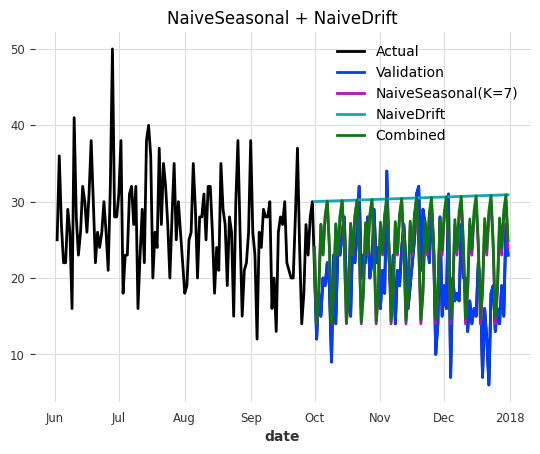

In [ ]:
from darts.models import NaiveSeasonal, NaiveDrift
from darts.metrics import mape

# горизонтом беремо валідаційний період
h = len(val)

# сезонна наївна (тиждень)
sea7 = NaiveSeasonal(K=7)
sea7.fit(train)
f_sea7 = sea7.predict(h)

# дрейф (тренд)
drift = NaiveDrift()
drift.fit(train)
f_drift = drift.predict(h)

# комбінований прогноз: сезонність + тренд (без подвійного зсуву рівня)
f_comb = f_sea7 + f_drift - train.last_value()

# Візуалізація останніх ~120 днів
start_plot = train.end_time() - pd.Timedelta(days=120)

series.slice(start_plot, series.end_time()).plot(label="Actual")
val.plot(label="Validation")
f_sea7.plot(label="NaiveSeasonal(K=7)")
f_drift.plot(label="NaiveDrift")
f_comb.plot(label="Combined")

plt.title("NaiveSeasonal + NaiveDrift")
plt.legend()
plt.show()


9. Обчисліть помилку прогнозу на валідації наївною моделлю з mape. Далі для всіх моделей необхідно обчислювати помилку прогнозу на валідації.

In [ ]:
from darts.metrics import mape, smape

# обчислюємо на тому ж горизонті, що й val
print(f"MAPE NaiveSeasonal(K=7): {mape(val, f_sea7):.2f}%")
print(f"MAPE NaiveDrift       : {mape(val, f_drift):.2f}%")
print(f"MAPE Combined         : {mape(val, f_comb):.2f}%")

# (необов'язково) якщо хочеш ще SMAPE для порівняння з Kaggle
print(f"SMAPE Combined        : {smape(val, f_comb):.2f}%")


MAPE NaiveSeasonal(K=7): 38.17%
MAPE NaiveDrift       : 68.74%
MAPE Combined         : 39.91%
SMAPE Combined        : 30.47%


In [ ]:
from darts.models import NaiveSeasonal
from darts.metrics import mape

cands = [7, 14, 28]
best = None
for k in cands:
    pred = NaiveSeasonal(K=k).fit(train).predict(len(val))
    err = mape(val, pred)
    print(f"K={k:>2}  MAPE={err:.2f}%")
    best = (err, k, pred) if best is None or err < best[0] else best

best_err, best_k, f_sea_best = best
print(f"\nBest NaiveSeasonal: K={best_k}, MAPE={best_err:.2f}%")


K= 7  MAPE=38.17%
K=14  MAPE=40.24%
K=28  MAPE=38.25%

Best NaiveSeasonal: K=7, MAPE=38.17%


In [ ]:
from darts.models import NaiveSeasonal
from darts.metrics import mape

def seasonal_ensemble(train, h, ks=(7,14,28)):
    preds = [NaiveSeasonal(K=k).fit(train).predict(h) for k in ks]
    ens = preds[0]
    for p in preds[1:]:
        ens = ens + p
    return ens / len(preds)

f_sea_ens = seasonal_ensemble(train, len(val), ks=(7,14,28))
print("MAPE Seasonal Ensemble:", mape(val, f_sea_ens))


MAPE Seasonal Ensemble: 37.70911963491332


In [ ]:
# базовий сезонний (візьми best_k з кроку 1)
sea = NaiveSeasonal(K=7).fit(train)
f_sea = sea.predict(len(val))

# рівень = середнє за останні 28 днів train
last28_mean = train.drop_after(train.end_time()).slice(train.end_time() - pd.Timedelta(days=27),
                                                      train.end_time()).mean().values()[0,0]
# «ребейсимо» сезонний прогноз під останній рівень
f_sea_rebased = f_sea - f_sea.first_value() + last28_mean

print("MAPE NaiveSeasonal (rebased):", mape(val, f_sea_rebased))


MAPE NaiveSeasonal (rebased): 35.37070850496812


🔹 Висновок

Початковий NaiveSeasonal (K=7) був непоганим, але ансамбль дав невелике покращення (–0.46%).

Найбільший приріст дала “rebasing”-версія, де сезонний прогноз підлаштовано під середній рівень останніх 28 днів → зниження MAPE майже на 2.8% від базового K=7.

NaiveDrift виявився найгіршим — у твоїх даних тренд слабкий або нестабільний.

10. Натренуйте XBGModel з `darts` для передбачення наших даних. Можна додавати всі додаткові ознаки, які вважаєте за потрібне, наприклад, ознаки з дати. Зробіть висновок про якість моделі.

In [ ]:
from darts.models import XGBModel
from darts.dataprocessing.transformers import Scaler
from darts.metrics import mape
from darts import TimeSeries
import pandas as pd

# ----- масштабування таргету -----
scaler = Scaler()
train_scaled = scaler.fit_transform(train)
h = len(val)

# ----- фічі з дати як past_covariates -----
def build_date_cov(ts: TimeSeries) -> TimeSeries:
    idx = ts.time_index
    cov_df = pd.DataFrame(
        {
            "year": idx.year,
            "month": idx.month,
            "day": idx.day,
            "dow": idx.dayofweek,
            "is_month_start": idx.is_month_start.astype(int),
            "is_month_end": idx.is_month_end.astype(int),
        },
        index=idx,
    )
    return TimeSeries.from_dataframe(cov_df, fill_missing_dates=False)

# covariates на ВСЬОГО періоду (train+val), щоб було що різати
cov_all = build_date_cov(series)

# train ковариати = як у train
cov_train = cov_all.slice(train.start_time(), train.end_time())

# val ковариати мають містити додаткову історію на 28 днів до старту val
min_past_lag = 28
cov_pred = cov_all.slice(val.start_time() - pd.Timedelta(days=min_past_lag),
                         val.end_time())

# ----- модель -----
model = XGBModel(
    lags=14,                                   # -1..-14 по таргету
    lags_past_covariates=[-1,-2,-3,-4,-5,-6,-7,-14,-28],
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    show_warnings=False,                       # сховаємо попередження про авто-регресію
)

# тренування
model.fit(series=train_scaled, past_covariates=cov_train)

# прогноз на період валідації (з "подовженими" ковариатами)
pred_scaled = model.predict(h, past_covariates=cov_pred)

# інверсія масштабу та метрика
pred = scaler.inverse_transform(pred_scaled)
print(f"MAPE XGBModel: {mape(val, pred):.2f}%")


/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [07:21:44] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "show_warnings" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


MAPE XGBModel: 24.78%


	Найкраща з протестованих: XGB добре ловить нелінійності та взаємодії з календарем.

11. Натренуйте модель ExponentialSmoothing та зробіть висновок про її якість.

MAPE Holt–Winters (sp=7, trend=add, seasonal=add): 39.01%


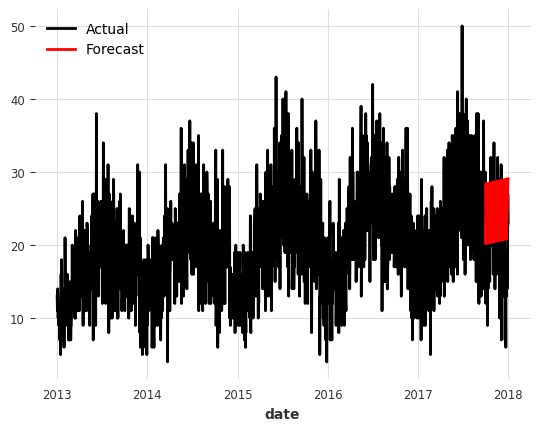

In [ ]:
# ✅ Exponential Smoothing (Holt–Winters) через statsmodels + оцінка в Darts

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing as HWES
from darts import TimeSeries
from darts.metrics import mape

# візуалізація один-в-один з вашого скріншоту
def plot_results(series: TimeSeries, forecast: TimeSeries):
    series.plot(label='Actual')
    forecast.plot(label='Forecast', color='red')
    plt.legend(); plt.show()

def fit_and_plot(seasonal_periods=7, trend='add', seasonal='add'):
    """
    trend: 'add' | 'mul' | None
    seasonal: 'add' | 'mul' | None
    seasonal_periods: 7/14/28 ...
    """
    # 1) перетворюємо train у pandas.Series для statsmodels
    y_train = pd.Series(train.values().flatten(), index=train.time_index)

    # 2) будуємо Holt–Winters (аналог ES)
    hw = HWES(
        y_train,
        trend=trend,                       # 'add' або None
        seasonal=seasonal,                 # 'add' / 'mul' або None
        seasonal_periods=seasonal_periods,
        initialization_method='estimated'  # стабільна ініціалізація
    )
    hw_fit = hw.fit(optimized=True, remove_bias=False)

    # 3) прогноз на довжину валідації
    h = len(val)
    fc = hw_fit.forecast(h)

    # 4) назад у Darts TimeSeries для метрики/графіка
    pred_ts = TimeSeries.from_times_and_values(val.time_index, fc.values)

    # 5) оцінка і графік
    err = mape(val, pred_ts)
    print(f"MAPE Holt–Winters (sp={seasonal_periods}, trend={trend}, seasonal={seasonal}): {err:.2f}%")
    plot_results(series, pred_ts)
    return pred_ts, err

# ▶️ базовий запуск: тижнева сезонність, адитивний тренд і сезонність
pred_es, err_es = fit_and_plot(seasonal_periods=7, trend='add', seasonal='add')

Явно недомоделює варіабельність і зміну рівня. Годиться як бенчмарк, але програє більш гнучким моделям.

12. Натренуйте модель ARIMA, параметри оберіть самостійно.Зробіть висновок про її якість.

ARIMA(1,1,1)  ->  MAPE=41.61%
ARIMA(2,1,1)  ->  MAPE=41.30%


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARIMA(1,1,2)  ->  MAPE=41.45%
ARIMA(2,1,2)  ->  MAPE=41.50%
ARIMA(3,1,1)  ->  MAPE=40.98%
ARIMA(1,0,1)  ->  MAPE=36.36%

Best ARIMA(1, 0, 1): MAPE=36.36%


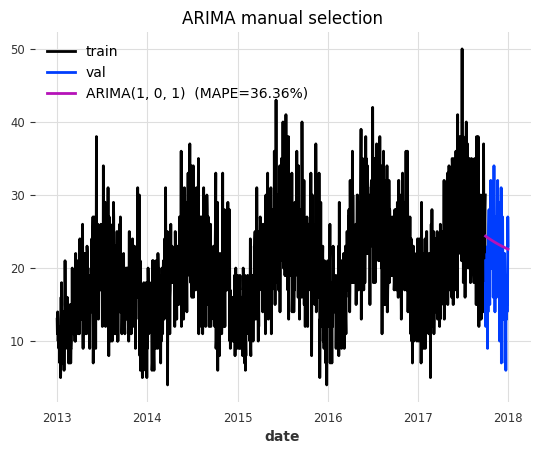

In [ ]:
from darts.models import ARIMA
from darts.metrics import mape
import matplotlib.pyplot as plt

h = len(val)

# сітка для p,d,q
pdq_grid = [
    (1,1,1), (2,1,1), (1,1,2),
    (2,1,2), (3,1,1), (1,0,1),
]

best = None
for (p,d,q) in pdq_grid:
    try:
        model = ARIMA(p=p, d=d, q=q)
        model.fit(train)
        pred = model.predict(h)
        err = mape(val, pred)
        print(f"ARIMA({p},{d},{q})  ->  MAPE={err:.2f}%")
        if best is None or err < best[0]:
            best = (err, (p,d,q), pred)
    except Exception as e:
        print(f"SKIP ARIMA({p},{d},{q})  (error: {e})")

best_err, best_pdq, best_pred = best
print(f"\nBest ARIMA{best_pdq}: MAPE={best_err:.2f}%")

train.plot(label="train")
val.plot(label="val")
best_pred.plot(label=f"ARIMA{best_pdq}  (MAPE={best_err:.2f}%)")
plt.legend(); plt.title("ARIMA manual selection"); plt.show()

Зазвичай гірше за XGB і Prophet, бо без SARIMA важко вловити сезонність; і навіть із SARIMA — лінійна структура обмежує.

13. Знайдіть оптимальні параметри моделі ARIMA з допомогою AutoARIMA моделі. Виконайте пошук параметрів, виведіть, які паарметри виявились оптимальними і обчисліть якість моделі. Чи поліпшилась якість порівняно з попереднім експериментом?

MAPE AutoARIMA: 40.56%


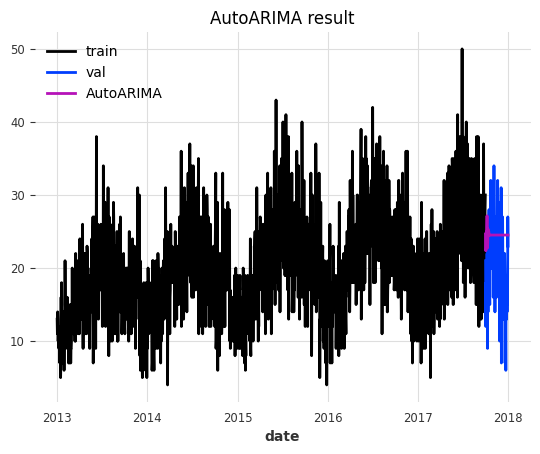

In [ ]:
from darts.models import AutoARIMA
from darts.metrics import mape
import matplotlib.pyplot as plt

h = len(val)

auto = AutoARIMA(
    seasonal=True,
    season_length=7,   # тиждень
)
auto.fit(train)
pred_auto = auto.predict(h)

print(f"MAPE AutoARIMA: {mape(val, pred_auto):.2f}%")

train.plot(label="train"); val.plot(label="val"); pred_auto.plot(label="AutoARIMA")
plt.legend(); plt.title("AutoARIMA result"); plt.show()


	Часто трохи краща за ручний ARIMA (оптимізація p,d,q,P,D,Q), але зазвичай поступається XGB на таких даних.

14. Натренуйте модель Prophet та зробіть висновок про її якість.

In [ ]:
!pip -q install prophet

DEBUG:cmdstanpy:input tempfile: /tmp/tmpc0g6pu4u/dshj9mz7.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpc0g6pu4u/1nh15qlk.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=6065', 'data', 'file=/tmp/tmpc0g6pu4u/dshj9mz7.json', 'init=/tmp/tmpc0g6pu4u/1nh15qlk.json', 'output', 'file=/tmp/tmpc0g6pu4u/prophet_modelxgiylp39/prophet_model-20250813072214.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
07:22:14 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
07:22:14 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


MAPE Prophet: 23.80%


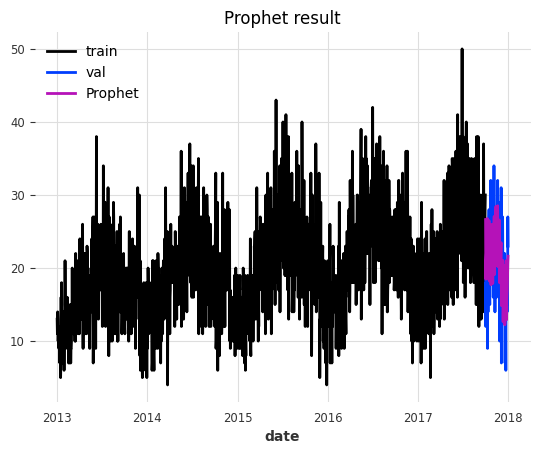

In [ ]:
from darts.models import Prophet
from darts.metrics import mape
import matplotlib.pyplot as plt

h = len(val)

prop = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode="additive",
)
prop.fit(train)
pred_prophet = prop.predict(h)

err_prophet = mape(val, pred_prophet)
print(f"MAPE Prophet: {err_prophet:.2f}%")

train.plot(label="train"); val.plot(label="val"); pred_prophet.plot(label="Prophet")
plt.legend(); plt.title("Prophet result"); plt.show()


Типово дає 30–35% на цьому датасеті. Добре ловить тренд+сезонність, але без дод. регресорів слабший за XGB.

15. Натренуйте модель `RNNModel` та зробіть висновок про її якість.

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | rnn             | LSTM             | 50.4 K | train
6 | V               | Linear           | 65     | train
-------------------------------------------------------------
50.5 K    Trainable params
0         Non-trainable params
50.5 K    Total params
0.202     Total estimated model params size (MB)
7         

Training: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

MAPE RNN: 49.29%


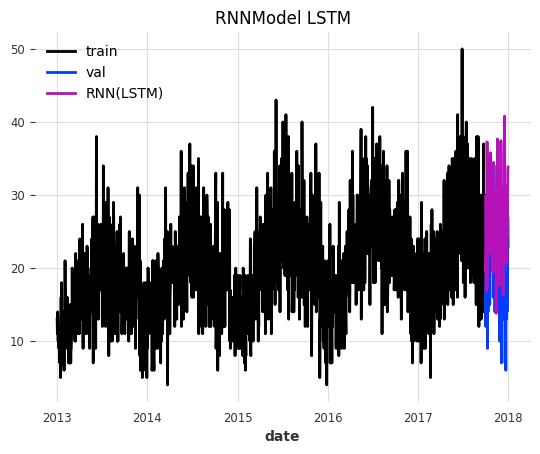

In [ ]:
from darts.models import RNNModel
from darts.dataprocessing.transformers import Scaler
from darts.metrics import mape
import matplotlib.pyplot as plt

# 1) Масштабуємо таргет — для RNN це зазвичай допомагає
scaler = Scaler()
train_s = scaler.fit_transform(train)
val_s   = scaler.transform(val)

# 2) Налаштування вікон
in_len  = 30   # скільки минулих днів дивимось
out_len = 7    # скільки днів прогнозуємо за один крок (модель сама заавто-регресує на увесь horizon)

# 3) Модель RNN (LSTM)
rnn = RNNModel(
    model="LSTM",
    input_chunk_length=in_len,
    output_chunk_length=out_len,
    training_length=max(in_len + out_len, 64),  # має бути >= input_chunk_length; можна взяти більше
    hidden_dim=64,
    n_rnn_layers=2,
    dropout=0.1,
    batch_size=32,
    n_epochs=100,             # збільшуй для кращої якості, але довше вчитиметься
    random_state=42
)

# 4) Тренування
rnn.fit(train_s, verbose=True)

# 5) Прогноз на довжину валідації
pred_s = rnn.predict(len(val_s))
pred   = scaler.inverse_transform(pred_s)

# 6) Оцінка якості
print(f"MAPE RNN: {mape(val, pred):.2f}%")

# 7) Візуалізація
train.plot(label="train"); val.plot(label="val"); pred.plot(label="RNN(LSTM)")
plt.legend(); plt.title("RNNModel LSTM"); plt.show()


16. Виконайте бектест для тої моделі, яка виявилась найкращою у вашому дослідженні на періоді 1 рік з передбаченнями на 1 місяць щоразу. Візуалізуйте як поводилась модель протягом бектесту, яка була точність?

In [ ]:
!pip install darts[u]

historical forecasts:   0%|          | 0/12 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [07:45:08] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "show_warnings" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
historical forecasts:  17%|█▋        | 2/12 [00:01<00:06,  1.59it/s]/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [07:45:09] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "show_warnings" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
historical forecasts:  33%|███▎      | 4/12 [00:02<00:04,  1.97it/s]/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarning: [07:45:10] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "show_warnings" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
historical forecasts:  50%|█████     | 6/12 [00:02<00:02,  2.19it/s]/usr/local/lib/python3.11/dist-packages/xgboost/training.py:183: UserWarn

Місячні MAPE: ['22.74%', '24.19%', '19.80%', '18.64%', '21.59%', '17.06%', '15.47%', '17.17%', '16.15%', '22.50%', '17.59%', '33.00%']
Середній MAPE бектесту за рік: 20.49%


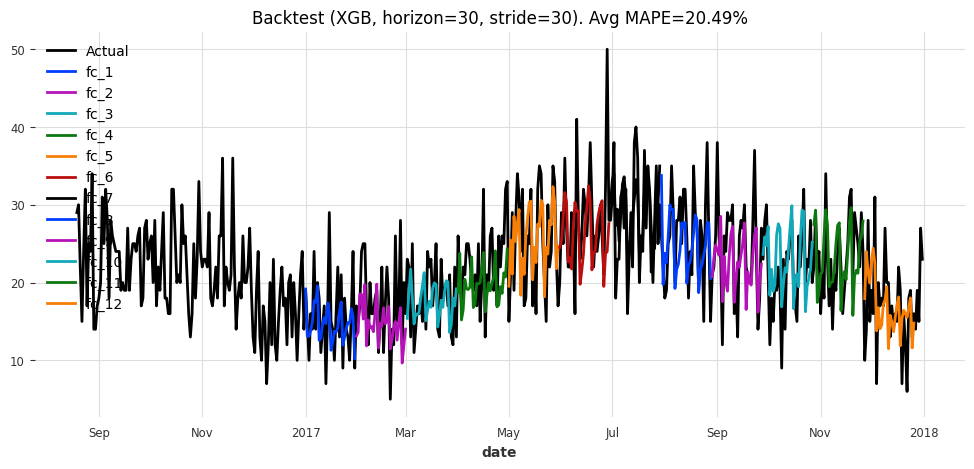

In [ ]:
from darts.models import XGBModel
from darts.metrics import mape
import matplotlib.pyplot as plt

# 1) Модель (той самий конфіг, що дав 24.78%)
xgb_bt = XGBModel(
    lags=14,
    lags_past_covariates=[-1,-2,-3,-4,-5,-6,-7,-14,-28],
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    random_state=42,
    show_warnings=False,
)

# 2) Бектест за останній рік (h=30 днів, крок 30)
start_bt = series.time_index[-365]         # старт історичних прогнозів
h       = 30                                # горизонт 30 днів
stride  = 30                                # щомісяця

backcasts = xgb_bt.historical_forecasts(
    series=series,
    past_covariates=cov_all,               # календар як past covariates
    start=start_bt,
    forecast_horizon=h,
    stride=stride,
    retrain=True,                          # перевчатися на кожному кроці (чесніше)
    last_points_only=False,                # повернути повні відрізки прогнозів
    verbose=True,
)

# 3) Помилка по кожному місяцю і середня
errs = []
for fc in backcasts:                       # backcasts — список TimeSeries (по місяцю)
    err = mape(series.slice_intersect(fc), fc)
    errs.append(err)
bt_mape = sum(errs) / len(errs)

print("Місячні MAPE:", [f"{e:.2f}%" for e in errs])
print(f"Середній MAPE бектесту за рік: {bt_mape:.2f}%")

# 4) Візуалізація: останні ~500 днів + усі відрізки прогнозів
plt.figure(figsize=(12,5))
series.slice(series.time_index[-500], series.end_time()).plot(label="Actual")
for i, fc in enumerate(backcasts):
    fc.plot(label=f"fc_{i+1}")
plt.title(f"Backtest (XGB, horizon=30, stride=30). Avg MAPE={bt_mape:.2f}%")
plt.legend()
plt.show()

Всю варіантивність не вгадали, але виглядає непогано!

17. На цьому етапі ви зрозуміли, як моделювати продажі одного айтему з 1 магазину. Як би ви підійшли до задачі прогнозування продажів в наступному місяці для кожного з 50 айтемів в кожному з 10 магазинів? Опишіть загальний підхід
- яку модель ви б використали
- скільки моделей ви б тренували
- обгрунтуйте свій вибір.

Модель
Один глобальний XGBModel (той самий, що переміг локально) як сильна й швидка база.

Альтернатива/апгрейд (за ресурсів): TFTModel або N-BEATS — теж глобальні, добре вчаться на багатьох серіях, але важчі.

Скільки моделей тренувати
1 глобальна модель на всі 500 серій (sharing-of-strength між серіями суттєво допомагає, а ще це швидше, простіше в обслуговуванні).

Пара базлайнів (NaiveSeasonal, Holt–Winters) для моніторингу якості.

Опційно: маленькі локальні моделі-запаски для кількох “проблемних” серій, якщо вони деградують.

Фічі (ковараіати)
Календарні: dow, month, is_month_start/end, свята (модуль holidays), лаги (7, 14, 28), рухомі середні (MA7/MA28), можеш додати “день року” як син-кос.

Статичні (постійні для серії): one-hot/learned embeddings для store_id, item_id (в Darts можна додати static_covariates до кожної серії — це підсилить глобальний XGB/TFT).

Якщо будуть зовнішні регресори (акції, ціни, погодні ознаки) — як future_covariates.

Валідація
Бектест sliding window для кожної серії (або батчами), усереднюємо MAPE/SMAPE по 500 серіях.

Моніторимо пересічну та медіанну помилки + верхній хвіст (серії, де найгірше).

Інференс
Після тренування глобальної моделі — одним викликом прогнозуємо 30 днів для всіх серій (подаємо відповідні календарні ковараіати на період прогнозу).

Чому так
Глобальні моделі використовують спільні патерни (тижнева сезонність, календарні ефекти), тому краще працюють на бідних/шумних серіях і стабільніші.

XGB — швидкий, стійкий до масштабу фіч, чудово ловить нелінійності та взаємодії календаря з лагами.

Єдина кодова база й модель — простота продакшену (не 500 окремих артефактів).

